Total cleaned clusters: 3308948
Photons: 1243837
Electrons: 444232
Hadrons: 1591479

Grid info:
z range = 0.0 to 25.0 radiation lengths


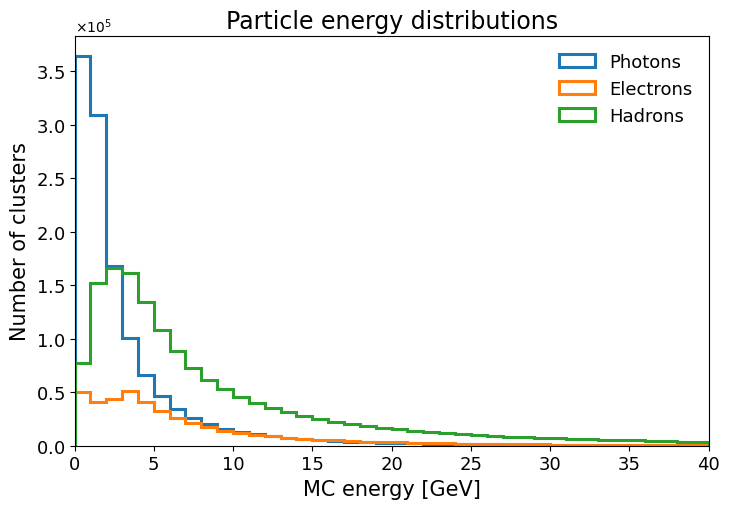

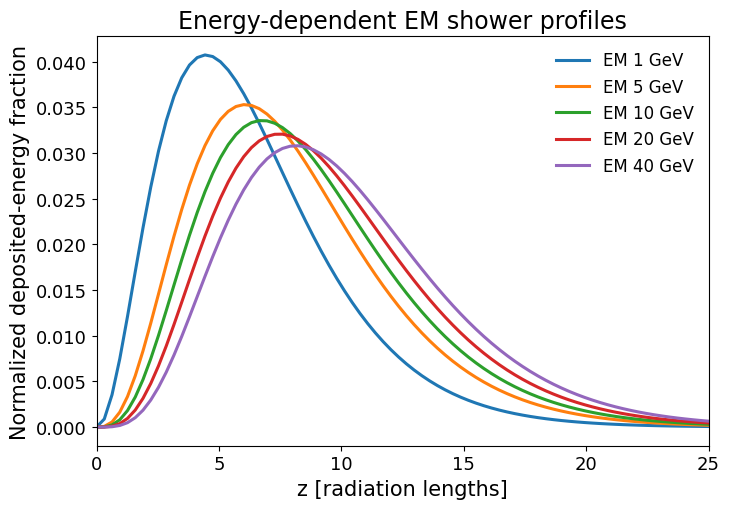


Hadron CSV columns:
Index(['nn', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8', 'e9', 'e10',
       'e11', 'e12', 'e13', 'e14', 'e15', 'e16', 'e17', 'e18', 'e19', 'e20',
       'e21', 'e22', 'e23', 'e24', 'e25', 'e26', 'e27', 'e28', 'e29', 'e30',
       'e31', 'e32', 'e33', 'e34', 'e35', 'e36', 'e37', 'e38', 'e39', 'e40'],
      dtype='str')
Raw hadron table shape: (66, 40)
Number of hadron energy profiles: 40
Number of layers: 66
Hadron simulation energies [GeV]:
[ 0.2  0.7  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5
 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5]
Hadron profiles on common z grid: (40, 80)
Normalization check: [1. 1. 1. 1. 1.]


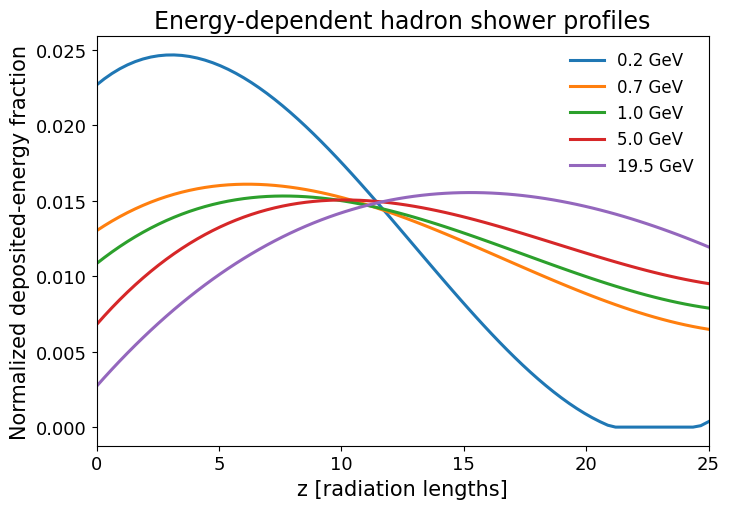

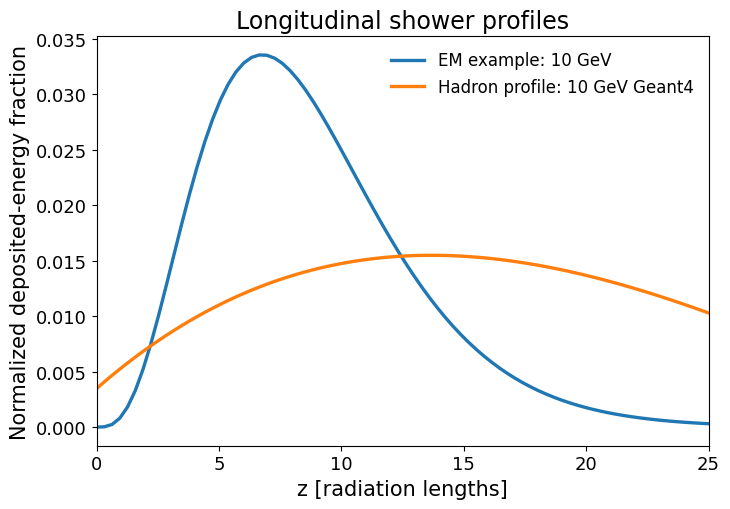


Photons: 1243837 clusters
Photons total MC weight: 4.3318574e+09
Photons mean MC energy [GeV]: 3.759955488470513
Photons median MC energy [GeV]: 1.7821759691455836
Photons Dose_xyz sum: 4331857263.861465

Electrons: 444232 clusters
Electrons total MC weight: 2.2489882e+09
Electrons mean MC energy [GeV]: 8.847445789900666
Electrons median MC energy [GeV]: 4.877575701312014
Electrons Dose_xyz sum: 2248988075.757769

Hadrons: 1591479 clusters
Hadrons total MC weight: 5.5547013e+09
Hadrons mean MC energy [GeV]: 11.468409345925467
Hadrons median MC energy [GeV]: 5.955001452159772
Hadrons max MC energy [GeV]: 1170.8782638954915

Hadron energy-bin contributions:
E center [GeV] | clusters | MC weight
    0.20      |    11543 | 4.8405e+06
    0.70      |    49402 | 2.9613e+07
    1.00      |    46554 | 3.3138e+07
    1.50      |    82223 | 6.5295e+07
    2.00      |    80083 | 8.0632e+07
    2.50      |    83139 | 1.0123e+08
    3.00      |    84836 | 1.2094e+08
    3.50      |    81098 | 1.31

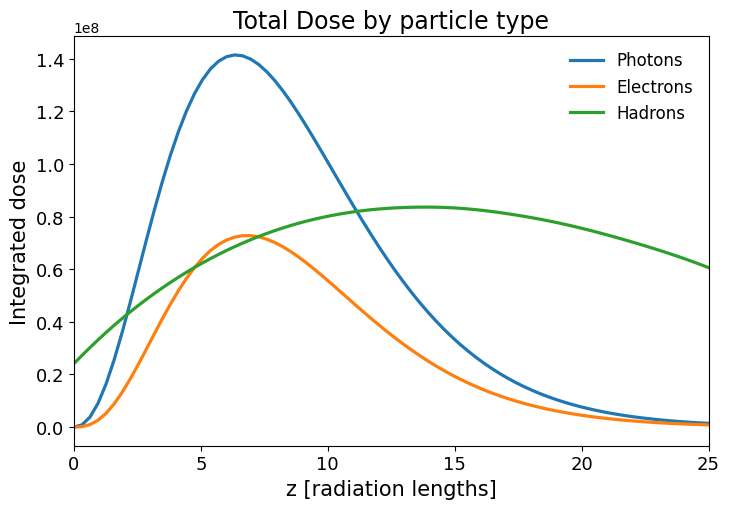

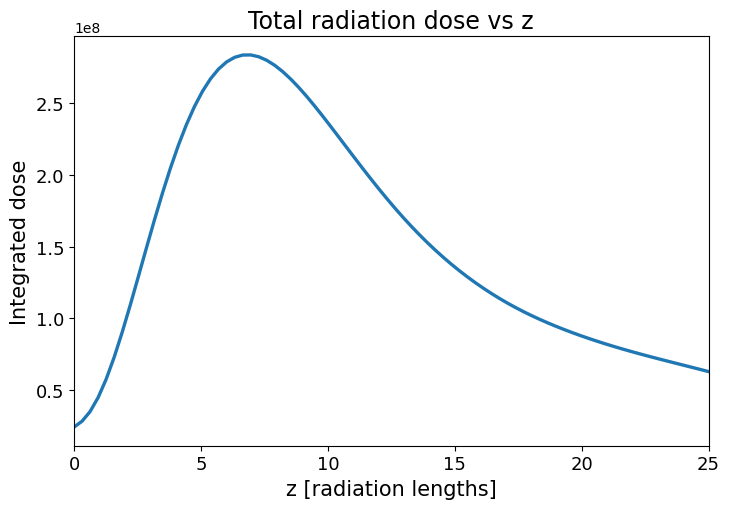

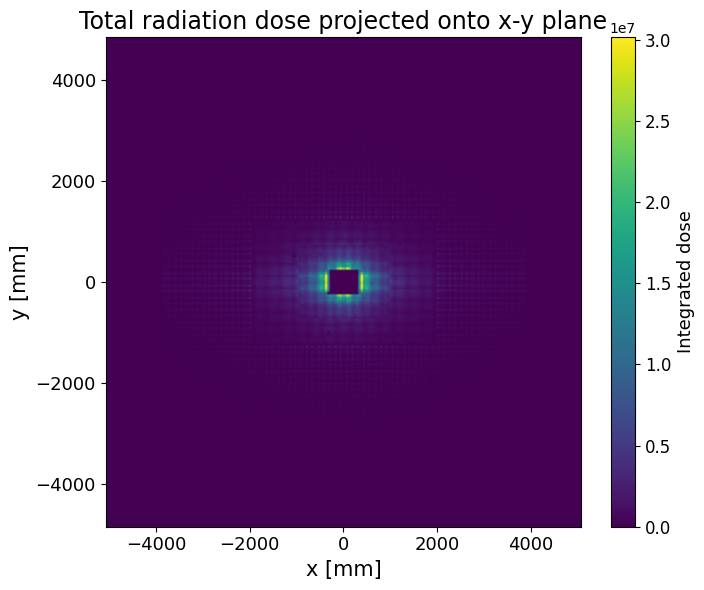

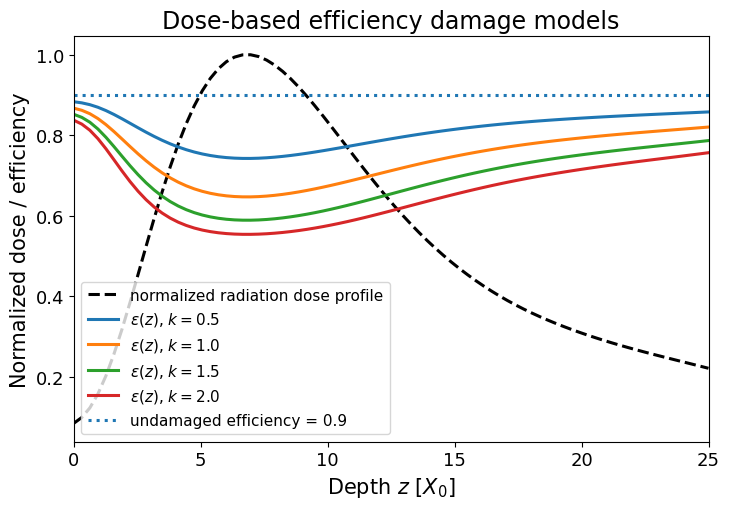


DONE: Updated model used energy-binned hadron Geant4 profiles.


In [3]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import gamma
from scipy.interpolate import UnivariateSpline
from matplotlib.ticker import ScalarFormatter



# \\\1. Load ROOT file


file_path = "/home/skiria/Downloads/neutralclassifier_training_tuple.root"
file = uproot.open(file_path)
tree = file["CaloClusterClassifierChecker/Clusters;1"]

x = tree["Cluster_x"].array(library="np")
y = tree["Cluster_y"].array(library="np")
pid = tree["Cluster_TRUEID"].array(library="np")

E_cluster_MeV = tree["Cluster_E"].array(library="np")
E_mc_MeV = tree["Cluster_MC_E"].array(library="np")

# Dose weight
weight = tree["Cluster_MC_weight"].array(library="np")



# 2. Clean positions and energies(To work with normal data and get rid of messy data)


clean_mask = (
    (np.abs(x) < 5000) &
    (np.abs(y) < 5000) &
    (E_mc_MeV > 0)
)

x = x[clean_mask]
y = y[clean_mask]
pid = pid[clean_mask]
weight = weight[clean_mask]
E_cluster_MeV = E_cluster_MeV[clean_mask]
E_mc_MeV = E_mc_MeV[clean_mask]

print("Total cleaned clusters:", len(weight))


# 3. Particle masks (divide particle types)


photon_mask = np.abs(pid) == 22
electron_mask = np.abs(pid) == 11
hadron_mask = np.abs(pid) > 22

print("Photons:", np.sum(photon_mask))
print("Electrons:", np.sum(electron_mask))
print("Hadrons:", np.sum(hadron_mask))


# 4. Units and common grid


MeV = 1.0
GeV = 1000.0 * MeV

margin = 200

x_abs = np.max(np.abs(x)) + margin
y_abs = np.max(np.abs(y)) + margin

Nx, Ny, Nz = 200, 200, 80

x_edges = np.linspace(-x_abs, x_abs, Nx + 1)
y_edges = np.linspace(-y_abs, y_abs, Ny + 1)

x_grid = 0.5 * (x_edges[:-1] + x_edges[1:])
y_grid = 0.5 * (y_edges[:-1] + y_edges[1:])

z = np.linspace(0, 25, Nz)

print("\nGrid info:")
print("z range =", z[0], "to", z[-1], "radiation lengths")



# 5. Plot to see particle energy distribution 


E_photon_GeV = E_mc_MeV[photon_mask] / GeV
E_electron_GeV = E_mc_MeV[electron_mask] / GeV
E_hadron_GeV = E_mc_MeV[hadron_mask] / GeV

bins_energy = np.arange(0, 41, 1)

plt.figure(figsize=(7.4, 5.2))

plt.hist(E_photon_GeV, bins=bins_energy, histtype="step",
         linewidth=2.2, label="Photons")
plt.hist(E_electron_GeV, bins=bins_energy, histtype="step",
         linewidth=2.2, label="Electrons")
plt.hist(E_hadron_GeV, bins=bins_energy, histtype="step",
         linewidth=2.2, label="Hadrons")

plt.xlim(0, 40)
plt.xlabel("MC energy [GeV]", fontsize=15)
plt.ylabel("Number of clusters", fontsize=15)
plt.title("Particle energy distributions", fontsize=17)

ax = plt.gca()
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

plt.tick_params(axis="both", labelsize=13)
plt.legend(fontsize=13, frameon=False)
plt.tight_layout()
plt.savefig("particle_energy_distribution_final.png", dpi=300, bbox_inches="tight")
plt.show()



# 6. Energy dependent Electromagnetic  shower model


critical_energy_MeV = 7.0
b_em = 0.5


def tmax_em(E_MeV):
    return np.maximum(np.log(E_MeV / critical_energy_MeV) - 0.5, 0.0)


def em_dedx_profile(z, E_MeV, b=b_em):
    E_MeV = np.asarray(E_MeV)

    tmax = tmax_em(E_MeV)
    a = b * tmax + 1.0

    if E_MeV.ndim == 0:
        profile = b * np.power(b * z, a - 1.0) * np.exp(-b * z) / gamma(a)
        profile[profile < 0] = 0
        profile /= np.sum(profile)
        return profile

    z2 = z[np.newaxis, :]
    a2 = a[:, np.newaxis]

    profile = b * np.power(b * z2, a2 - 1.0) * np.exp(-b * z2) / gamma(a2)
    profile[profile < 0] = 0

    norm = np.sum(profile, axis=1)
    norm[norm == 0] = 1.0

    profile = profile / norm[:, np.newaxis]

    return profile


plt.figure(figsize=(7.4, 5.2))

for E_GeV in [1, 5, 10, 20, 40]:
    f_test = em_dedx_profile(z, E_GeV * GeV)
    plt.plot(z, f_test, linewidth=2.2, label=f"EM {E_GeV} GeV")

plt.xlim(0, 25)
plt.xlabel("z [radiation lengths]", fontsize=15)
plt.ylabel("Normalized deposited-energy fraction", fontsize=15)
plt.title("Energy-dependent EM shower profiles", fontsize=17)
plt.tick_params(axis="both", labelsize=13)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("em_energy_dependent_profiles.png", dpi=300, bbox_inches="tight")
plt.show()




# 7. Energy-dependent hadron profiles from CSV file(From Geant4 simulation)


hadron_csv_path = "/home/skiria/Downloads/result40sxs1.csv"

# Read CSV file
df_had = pd.read_csv(hadron_csv_path)

print("\nHadron CSV columns:")
print(df_had.columns)

# First column is assumed to be layer index: nn
layer_index = df_had.iloc[:, 0].to_numpy(dtype=float)

# Remaining columns are energy profiles
hadron_profile_raw = df_had.iloc[:, 1:].to_numpy(dtype=float)

# Shape: 66 layers x N energies
print("Raw hadron table shape:", hadron_profile_raw.shape)

hadron_profiles_layers = hadron_profile_raw.T

n_had_energies, n_had_layers = hadron_profiles_layers.shape

print("Number of hadron energy profiles:", n_had_energies)
print("Number of layers:", n_had_layers)

# Automatically choose energy list depending on number of columns
if n_had_energies == 40:
    hadron_sim_energies_GeV = np.array([0.2, 0.7] + list(np.arange(1.0, 20.0, 0.5)))
elif n_had_energies == 41:
    hadron_sim_energies_GeV = np.array([0.2, 0.7] + list(np.arange(1.0, 20.5, 0.5)))
else:
    raise ValueError(
        f"Unexpected number of hadron profiles: {n_had_energies}. "
        "Please define hadron_sim_energies_GeV manually."
    )

print("Hadron simulation energies [GeV]:")
print(hadron_sim_energies_GeV)

z_hadron_layers = np.linspace(0, 25, n_had_layers)


def smooth_hadron_profile(y_layers, smoothing_strength=0.15):
    y_layers = np.asarray(y_layers, dtype=float)
    y_layers[y_layers < 0] = 0

    s_val = smoothing_strength * len(y_layers) * np.var(y_layers)

    spline = UnivariateSpline(
        z_hadron_layers,
        y_layers,
        s=s_val
    )

    y_smooth = spline(z)
    y_smooth[y_smooth < 0] = 0

    if np.sum(y_smooth) == 0:
        y_smooth[:] = 1.0

    y_smooth /= np.sum(y_smooth)

    return y_smooth


hadron_profiles_z = np.array([
    smooth_hadron_profile(profile)
    for profile in hadron_profiles_layers
])

print("Hadron profiles on common z grid:", hadron_profiles_z.shape)
print("Normalization check:", np.sum(hadron_profiles_z, axis=1)[:5])


# Plot some hadron profiles
plt.figure(figsize=(7.4, 5.2))

for E_show in [0.2, 0.7, 1, 5, 19.5]:
    idx = np.argmin(np.abs(hadron_sim_energies_GeV - E_show))
    plt.plot(
        z,
        hadron_profiles_z[idx],
        linewidth=2.2,
        label=f"{hadron_sim_energies_GeV[idx]:.1f} GeV"
    )

plt.xlim(0, 25)
plt.xlabel("z [radiation lengths]", fontsize=15)
plt.ylabel("Normalized deposited-energy fraction", fontsize=15)
plt.title("Energy-dependent hadron shower profiles", fontsize=17)
plt.tick_params(axis="both", labelsize=13)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("hadron_energy_dependent_profiles.png", dpi=300, bbox_inches="tight")
plt.show()


# 8. Comparison between developed EM and hadron profiles for 10Gev


f_z_em_10GeV = em_dedx_profile(z, 10 * GeV)

idx_had_10 = np.argmin(np.abs(hadron_sim_energies_GeV - 10.0))
f_z_had_10GeV = hadron_profiles_z[idx_had_10]

plt.figure(figsize=(7.4, 5.2))

plt.plot(z, f_z_em_10GeV, linewidth=2.4, label="EM example: 10 GeV")
plt.plot(z, f_z_had_10GeV, linewidth=2.4, label="Hadron profile: 10 GeV Geant4")

plt.xlim(0, 25)
plt.xlabel("z [radiation lengths]", fontsize=15)
plt.ylabel("Normalized deposited-energy fraction", fontsize=15)
plt.title("Longitudinal shower profiles", fontsize=17)
plt.tick_params(axis="both", labelsize=13)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("em_vs_hadron_10gev_profile.png", dpi=300, bbox_inches="tight")
plt.show()



# 9. Dose builder for energy-dependent EM particles - to aquire total radiation dose


def build_em_dose_energy_dependent(mask, name):
    x_sel = x[mask]
    y_sel = y[mask]
    w_sel = weight[mask]
    E_sel = E_mc_MeV[mask]

    print(f"\n{name}: {len(w_sel)} clusters")
    print(f"{name} total MC weight:", np.sum(w_sel))
    print(f"{name} mean MC energy [GeV]:", np.mean(E_sel) / GeV)
    print(f"{name} median MC energy [GeV]:", np.median(E_sel) / GeV)

    profiles = em_dedx_profile(z, E_sel)

    Dose_xyz = np.zeros((Nx, Ny, Nz))

    for iz in range(Nz):
        H_xy_z, _, _ = np.histogram2d(
            x_sel,
            y_sel,
            bins=[x_edges, y_edges],
            weights=w_sel * profiles[:, iz]
        )

        Dose_xyz[:, :, iz] = H_xy_z

    print(f"{name} Dose_xyz sum:", np.sum(Dose_xyz))

    return Dose_xyz



# 10. Dose builder for energy-binned hadrons


def build_hadron_dose_energy_binned(mask, name="Hadrons"):
    x_sel = x[mask]
    y_sel = y[mask]
    w_sel = weight[mask]
    E_sel_GeV = E_mc_MeV[mask] / GeV

    print(f"\n{name}: {len(w_sel)} clusters")
    print(f"{name} total MC weight:", np.sum(w_sel))
    print(f"{name} mean MC energy [GeV]:", np.mean(E_sel_GeV))
    print(f"{name} median MC energy [GeV]:", np.median(E_sel_GeV))
    print(f"{name} max MC energy [GeV]:", np.max(E_sel_GeV))

    E_centers = hadron_sim_energies_GeV

    E_edges = np.zeros(len(E_centers) + 1)
    E_edges[1:-1] = 0.5 * (E_centers[:-1] + E_centers[1:])
    E_edges[0] = 0.0
    E_edges[-1] = np.inf

    Dose_xyz = np.zeros((Nx, Ny, Nz))

    print("\nHadron energy-bin contributions:")
    print("E center [GeV] | clusters | MC weight")

    for i, E_center in enumerate(E_centers):
        bin_mask = (E_sel_GeV >= E_edges[i]) & (E_sel_GeV < E_edges[i + 1])

        if not np.any(bin_mask):
            continue

        x_bin = x_sel[bin_mask]
        y_bin = y_sel[bin_mask]
        w_bin = w_sel[bin_mask]

        H_xy, _, _ = np.histogram2d(
            x_bin,
            y_bin,
            bins=[x_edges, y_edges],
            weights=w_bin
        )

        f_z_bin = hadron_profiles_z[i]

        Dose_xyz += H_xy[:, :, np.newaxis] * f_z_bin[np.newaxis, np.newaxis, :]

        print(
            f"{E_center:8.2f}      | "
            f"{len(w_bin):8d} | "
            f"{np.sum(w_bin):.4e}"
        )

    print(f"{name} Dose_xyz sum:", np.sum(Dose_xyz))

    return Dose_xyz


# 11. Build dose maps


Dose_photon = build_em_dose_energy_dependent(photon_mask, "Photons")
Dose_electron = build_em_dose_energy_dependent(electron_mask, "Electrons")
Dose_hadron = build_hadron_dose_energy_binned(hadron_mask, "Hadrons")

Dose_total = Dose_photon + Dose_electron + Dose_hadron

print("\nTotal dose sum:", np.sum(Dose_total))
print("Total input MC weight:", np.sum(weight))


# 12. Dose vs z by particle type


Dose_z_photon = np.sum(Dose_photon, axis=(0, 1))
Dose_z_electron = np.sum(Dose_electron, axis=(0, 1))
Dose_z_hadron = np.sum(Dose_hadron, axis=(0, 1))

plt.figure(figsize=(7.4, 5.2))

plt.plot(z, Dose_z_photon, linewidth=2.3, label="Photons")
plt.plot(z, Dose_z_electron, linewidth=2.3, label="Electrons")
plt.plot(z, Dose_z_hadron, linewidth=2.3, label="Hadrons")

plt.xlim(0, 25)
plt.xlabel("z [radiation lengths]", fontsize=15)
plt.ylabel("Integrated dose", fontsize=15)
plt.title("Total Dose by particle type", fontsize=17)
plt.tick_params(axis="both", labelsize=13)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("totaldoseperZperType_updated.png", dpi=300, bbox_inches="tight")
plt.show()


# 13. Total z profile (toral radiation dose for all particles)


Dose_z = np.sum(Dose_total, axis=(0, 1))

plt.figure(figsize=(7.4, 5.2))

plt.plot(z, Dose_z, linewidth=2.4)

plt.xlim(0, 25)
plt.xlabel("z [radiation lengths]", fontsize=15)
plt.ylabel("Integrated dose", fontsize=15)
plt.title("Total radiation dose vs z", fontsize=17)
plt.tick_params(axis="both", labelsize=13)
plt.tight_layout()
plt.savefig("totaldoseperZ_updated.png", dpi=300, bbox_inches="tight")
plt.show()



# 14. Total x-y dose projected map


Dose_xy = np.sum(Dose_total, axis=2)

plt.figure(figsize=(7.2, 6.0))

im = plt.imshow(
    Dose_xy.T,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im)
cbar.set_label("Integrated dose", fontsize=13)
cbar.ax.tick_params(labelsize=12)

plt.xlabel("x [mm]", fontsize=15)
plt.ylabel("y [mm]", fontsize=15)
plt.title("Total radiation dose projected onto x-y plane", fontsize=17)
plt.tick_params(axis="both", labelsize=13)
plt.tight_layout()
plt.savefig("TotalXYdose_updated.png", dpi=300, bbox_inches="tight")
plt.show()



# 15. Dose-based efficiency model (Damage coefficient 1 used in the project arbitrarily)


Dose_z_norm = Dose_z / np.max(Dose_z)

epsilon_0 = 0.9
epsilon_min = 0.5

plt.figure(figsize=(7.4, 5.2))

plt.plot(
    z,
    Dose_z_norm,
    "k--",
    linewidth=2.2,
    label="normalized radiation dose profile"
)

for k in [0.5, 1.0, 1.5, 2.0]:
    epsilon_z = epsilon_min + (epsilon_0 - epsilon_min) * np.exp(-k * Dose_z_norm)
    plt.plot(z, epsilon_z, linewidth=2.2, label=fr"$\epsilon(z)$, $k={k}$")

plt.axhline(epsilon_0, linestyle=":", linewidth=2.2, label="undamaged efficiency = 0.9")

plt.xlim(0, 25)
plt.xlabel(r"Depth $z$ [$X_0$]", fontsize=15)
plt.ylabel("Normalized dose / efficiency", fontsize=15)
plt.title("Dose-based efficiency damage models", fontsize=17)
plt.tick_params(axis="both", labelsize=13)
plt.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("Dosetoefficiency_updated.png", dpi=300, bbox_inches="tight")
plt.show()


print("\nDONE: Updated model used energy-binned hadron Geant4 profiles.")

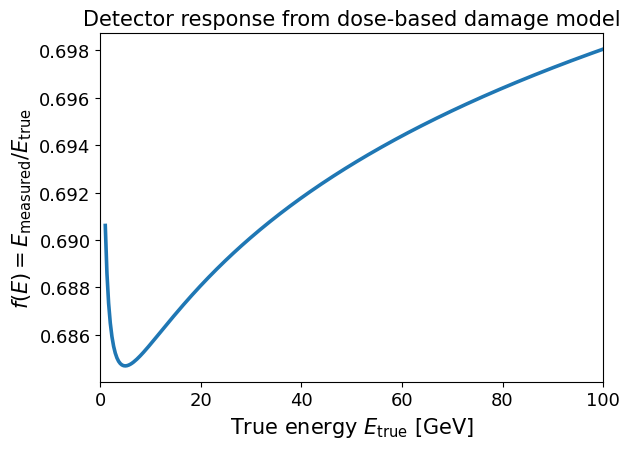

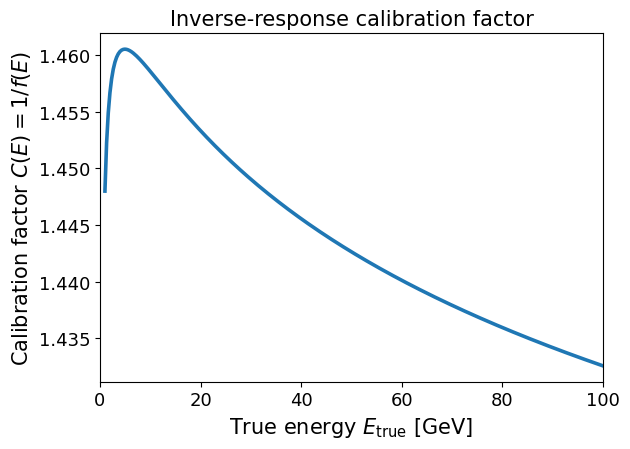

In [7]:
import matplotlib.pyplot as plt


# C. Calculation of f(Etrue) = Emeasured / Etrue


E_true_GeV = np.linspace(1, 100, 300)
E_true_MeV = E_true_GeV * GeV

f_response = []

for E in E_true_MeV:
    profile = em_dedx_profile(z, E)

    # Because profile is normalized, this is directly Emeasured / Etrue
    f = np.sum(epsilon_z * profile)

    f_response.append(f)

f_response = np.array(f_response)

E_measured_GeV = f_response * E_true_GeV
calibration_factor = 1.0 / f_response



#  plot 1: detector response


plt.figure(figsize=(6.4, 4.6))

plt.plot(
    E_true_GeV,
    f_response,
    linewidth=2.6
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"$f(E)=E_{\mathrm{measured}}/E_{\mathrm{true}}$", fontsize=15)
plt.title("Detector response from dose-based damage model", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)

plt.tight_layout()
plt.savefig("response_curve_clean.png", dpi=300, bbox_inches="tight")
plt.show()



#  plot 2: inverse-response same as- calibration factor


plt.figure(figsize=(6.4, 4.6))

plt.plot(
    E_true_GeV,
    calibration_factor,
    linewidth=2.6
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"Calibration factor $C(E)=1/f(E)$", fontsize=15)
plt.title("Inverse-response calibration factor", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)

plt.tight_layout()
plt.savefig("calibration_factor_clean.png", dpi=300, bbox_inches="tight")
plt.show()

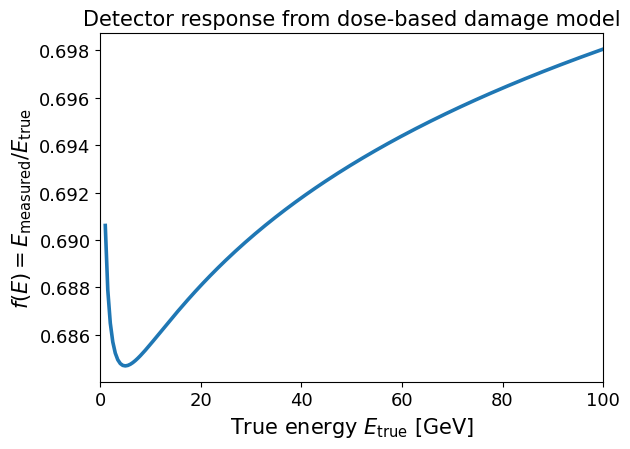

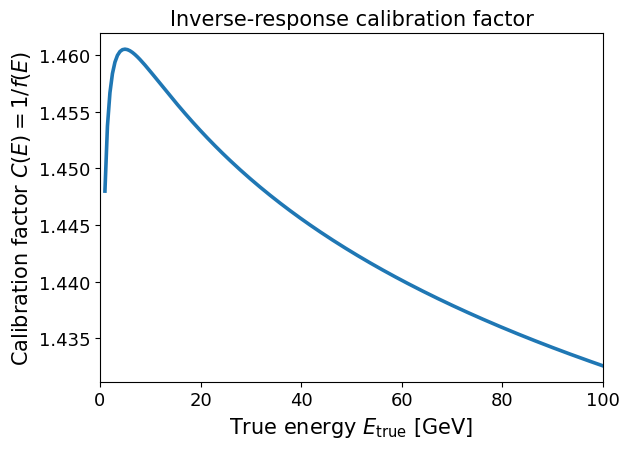


=== Log-polynomial degree 3 fit to response function ===
Fit form:
f(E) = a0 + a1 log(E) + a2 log(E)^2 + a3 log(E)^3

Parameters with statistical errors:
a0 = 0.6905542187 ± 0.0000072663
a1 = -0.0076838489 ± 0.0000096454
a2 = 0.0027861424 ± 0.0000039242
a3 = -0.0001662085 ± 0.0000004809

RMS residual = 9.469103e-06
chi2/dof = 200.00/196 = 1.020


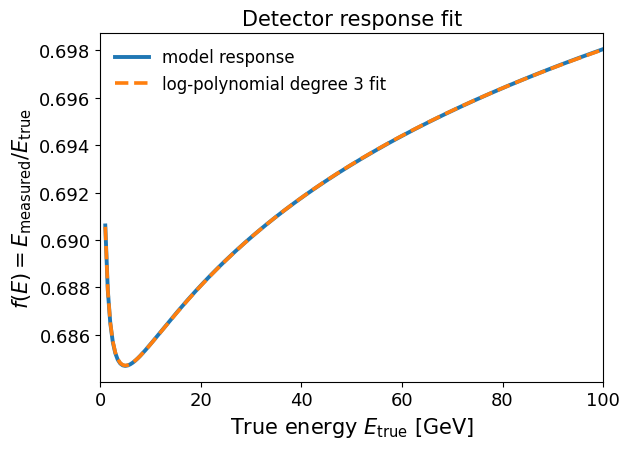


=== Common response parameterization fit ===
Fit form:
f(E) = 1 / (alpha + gamma/E)

Parameters with statistical errors:
alpha = 1.4421736576 ± 0.0005814759
gamma = 0.0390085579 ± 0.0052906708

RMS residual = 3.530943e-03
chi2/dof = 200.00/198 = 1.010


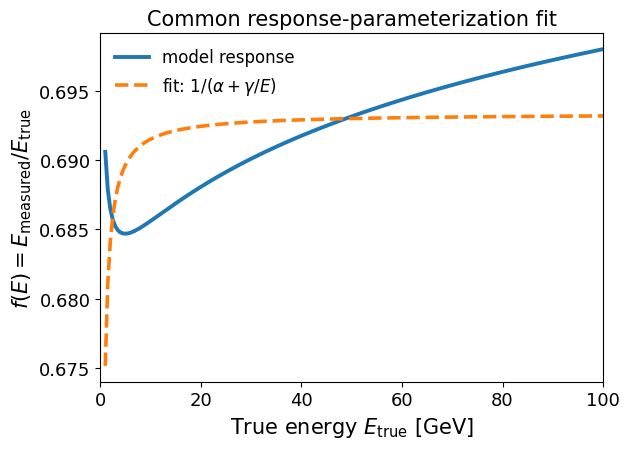

In [5]:

# 16. Detector response, calibration factor and fitting


from scipy.optimize import curve_fit


# Choose damage model used for final response (k=1)


k_final = 1.0

epsilon_z = epsilon_min + (epsilon_0 - epsilon_min) * np.exp(-k_final * Dose_z_norm)


# Calculate detector response for EM particles from 1 to 100 GeV


E_true_GeV = np.linspace(1, 100, 200)
E_true_MeV = E_true_GeV * GeV

f_response = []

for E_MeV in E_true_MeV:
    shower_profile = em_dedx_profile(z, E_MeV)

    # E_measured / E_true = integral epsilon(z) * normalized dE/dz dz
    f_E = np.sum(epsilon_z * shower_profile)

    f_response.append(f_E)

f_response = np.array(f_response)

calibration_factor = 1.0 / f_response



# 17.  response and calibration plots


plt.figure(figsize=(6.4, 4.6))

plt.plot(E_true_GeV, f_response, linewidth=2.6)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"$f(E)=E_{\mathrm{measured}}/E_{\mathrm{true}}$", fontsize=15)
plt.title("Detector response from dose-based damage model", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)

plt.tight_layout()
plt.savefig("response_curve_clean.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(6.4, 4.6))

plt.plot(E_true_GeV, calibration_factor, linewidth=2.6)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"Calibration factor $C(E)=1/f(E)$", fontsize=15)
plt.title("Inverse-response calibration factor", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)

plt.tight_layout()
plt.savefig("calibration_factor_clean.png", dpi=300, bbox_inches="tight")
plt.show()



# 18. Fit response function with log-polynomial degree 3


def log_poly3(E, a0, a1, a2, a3):
    L = np.log(E)
    return a0 + a1 * L + a2 * L**2 + a3 * L**3


# Fit response curve
popt, pcov = curve_fit(
    log_poly3,
    E_true_GeV,
    f_response,
    p0=[0.63, 0.01, -0.001, 0.0001],
    maxfev=10000
)

perr = np.sqrt(np.diag(pcov))

f_fit = log_poly3(E_true_GeV, *popt)


# Chi2/dof estimate

# Since this is a deterministic model curve, there are no experimental
# point-by-point uncertainties. We estimate chi2 using a constant
# numerical uncertainty equal to the RMS residual.

residuals = f_response - f_fit
rms_residual = np.sqrt(np.mean(residuals**2))

sigma_eff = rms_residual
chi2 = np.sum((residuals / sigma_eff)**2)
dof = len(E_true_GeV) - len(popt)
chi2_dof = chi2 / dof

print("\n=== Log-polynomial degree 3 fit to response function ===")
print("Fit form:")
print("f(E) = a0 + a1 log(E) + a2 log(E)^2 + a3 log(E)^3")
print("\nParameters with statistical errors:")
print(f"a0 = {popt[0]:.10f} ± {perr[0]:.10f}")
print(f"a1 = {popt[1]:.10f} ± {perr[1]:.10f}")
print(f"a2 = {popt[2]:.10f} ± {perr[2]:.10f}")
print(f"a3 = {popt[3]:.10f} ± {perr[3]:.10f}")
print(f"\nRMS residual = {rms_residual:.6e}")
print(f"chi2/dof = {chi2:.2f}/{dof} = {chi2_dof:.3f}")



# 19. Plot fitted response function


plt.figure(figsize=(6.4, 4.6))

plt.plot(
    E_true_GeV,
    f_response,
    linewidth=2.8,
    label="model response"
)

plt.plot(
    E_true_GeV,
    f_fit,
    linestyle="--",
    linewidth=2.6,
    label="log-polynomial degree 3 fit"
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"$f(E)=E_{\mathrm{measured}}/E_{\mathrm{true}}$", fontsize=15)
plt.title("Detector response fit", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)

plt.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig("response_fit_logpoly3_clean.png", dpi=300, bbox_inches="tight")
plt.show()



# 20. Comparison with commonly used parameterization based on energy


def common_response_model(E, alpha, gamma_param):
    return 1.0 / (alpha + gamma_param / E)


popt_common, pcov_common = curve_fit(
    common_response_model,
    E_true_GeV,
    f_response,
    p0=[1.55, 1.0],
    maxfev=10000
)

perr_common = np.sqrt(np.diag(pcov_common))

f_common = common_response_model(E_true_GeV, *popt_common)

res_common = f_response - f_common
rms_common = np.sqrt(np.mean(res_common**2))

sigma_eff_common = rms_common
chi2_common = np.sum((res_common / sigma_eff_common)**2)
dof_common = len(E_true_GeV) - len(popt_common)
chi2_dof_common = chi2_common / dof_common

print("\n=== Common response parameterization fit ===")
print("Fit form:")
print("f(E) = 1 / (alpha + gamma/E)")
print("\nParameters with statistical errors:")
print(f"alpha = {popt_common[0]:.10f} ± {perr_common[0]:.10f}")
print(f"gamma = {popt_common[1]:.10f} ± {perr_common[1]:.10f}")
print(f"\nRMS residual = {rms_common:.6e}")
print(f"chi2/dof = {chi2_common:.2f}/{dof_common} = {chi2_dof_common:.3f}")


plt.figure(figsize=(6.4, 4.6))

plt.plot(
    E_true_GeV,
    f_response,
    linewidth=2.8,
    label="model response"
)

plt.plot(
    E_true_GeV,
    f_common,
    linestyle="--",
    linewidth=2.6,
    label=r"fit: $1/(\alpha+\gamma/E)$"
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"$f(E)=E_{\mathrm{measured}}/E_{\mathrm{true}}$", fontsize=15)
plt.title("Common response-parameterization fit", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)

plt.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig("response_fit_common_clean.png", dpi=300, bbox_inches="tight")
plt.show()


=== Pi0-anchored calibration ===
Effective pi0 calibration energy = 10.0 GeV
Raw response at anchor energy f(10 GeV) = 0.685612
After pi0 anchoring: f_cal(10 GeV) = 1.000000

Residual calibrated response range:
min f_cal(E) = 0.99866380946568
max f_cal(E) = 1.0181253029556243

Residual calibration factor range:
min C_res(E) = 0.9821973750156229
max C_res(E) = 1.0013379783282974


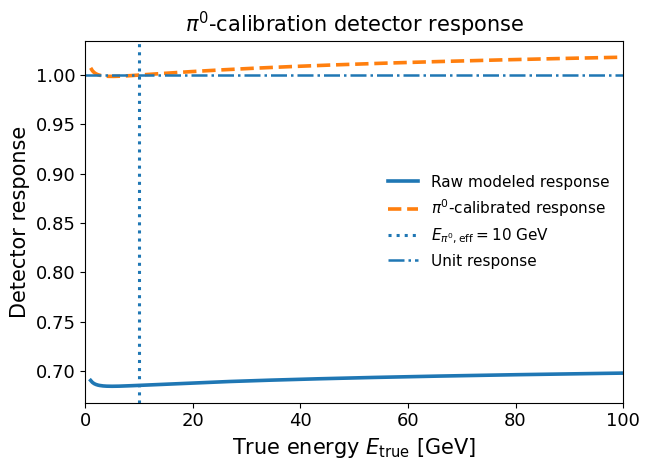

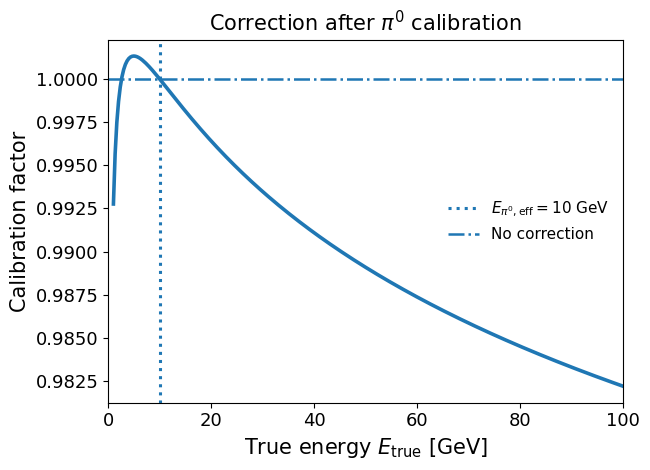

In [8]:
# 21. Pi0-calibrated response normalization


# Effective pi0 calibration energy assumption
E_pi0_eff_GeV = 10.0

# Interpolate raw response at 10 GeV
f_pi0_anchor = np.interp(E_pi0_eff_GeV, E_true_GeV, f_response)

# Pi0 calibration with the response to 1 at this energy
f_response_pi0_calibrated = f_response / f_pi0_anchor

# Corresponding residual calibration factor
C_pi0_residual = 1.0 / f_response_pi0_calibrated

print("\n=== Pi0-anchored calibration ===")
print(f"Effective pi0 calibration energy = {E_pi0_eff_GeV:.1f} GeV")
print(f"Raw response at anchor energy f(10 GeV) = {f_pi0_anchor:.6f}")
print("After pi0 anchoring: f_cal(10 GeV) = 1.000000")

print("\nResidual calibrated response range:")
print("min f_cal(E) =", np.min(f_response_pi0_calibrated))
print("max f_cal(E) =", np.max(f_response_pi0_calibrated))

print("\nResidual calibration factor range:")
print("min C_res(E) =", np.min(C_pi0_residual))
print("max C_res(E) =", np.max(C_pi0_residual))



# 22. Plot raw response and pi0-calibrated response


plt.figure(figsize=(6.6, 4.8))

plt.plot(
    E_true_GeV,
    f_response,
    linewidth=2.6,
    label="Raw modeled response"
)

plt.plot(
    E_true_GeV,
    f_response_pi0_calibrated,
    linewidth=2.6,
    linestyle="--",
    label=r"$\pi^0$-calibrated response"
)

plt.axvline(
    E_pi0_eff_GeV,
    linestyle=":",
    linewidth=2.2,
    label=r"$E_{\pi^0,\mathrm{eff}}=10$ GeV"
)

plt.axhline(
    1.0,
    linestyle="-.",
    linewidth=1.8,
    label="Unit response"
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"Detector response", fontsize=15)
plt.title(r"$\pi^0$-calibration detector response", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)

plt.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("pi0_anchored_response.png", dpi=300, bbox_inches="tight")
plt.show()



# 23. Plot calibration factor after pi0 calibration


plt.figure(figsize=(6.6, 4.8))

plt.plot(
    E_true_GeV,
    C_pi0_residual,
    linewidth=2.6
)

plt.axvline(
    E_pi0_eff_GeV,
    linestyle=":",
    linewidth=2.2,
    label=r"$E_{\pi^0,\mathrm{eff}}=10$ GeV"
)

plt.axhline(
    1.0,
    linestyle="-.",
    linewidth=1.8,
    label="No correction"
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"Calibration factor", fontsize=15)
plt.title(r"Correction after $\pi^0$ calibration", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)

plt.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("pi0_residual_calibration_factor.png", dpi=300, bbox_inches="tight")
plt.show()


=== Pi0-calibrated log-polynomial degree 3 fit ===
Fit form:
f_pi0(E) = a0 + a1 log(E) + a2 log(E)^2 + a3 log(E)^3

Parameters with fit errors:
a0 = 1.0071942480 ± 0.0000089143
a1 = -0.0111897890 ± 0.0000117128
a2 = 0.0040575497 ± 0.0000047068
a3 = -0.0002417501 ± 0.0000005721

RMS residual = 1.335363e-05
chi2/dof = 300.00/296 = 1.014

=== Pi0-calibrated common response parameterization fit ===
Fit form:
f_pi0(E) = 1 / (alpha + gamma/E)

Parameters with fit errors:
alpha = 0.9886777279 ± 0.0003227484
gamma = 0.0293050044 ± 0.0030640900

RMS residual = 5.085078e-03
chi2/dof = 300.00/298 = 1.007


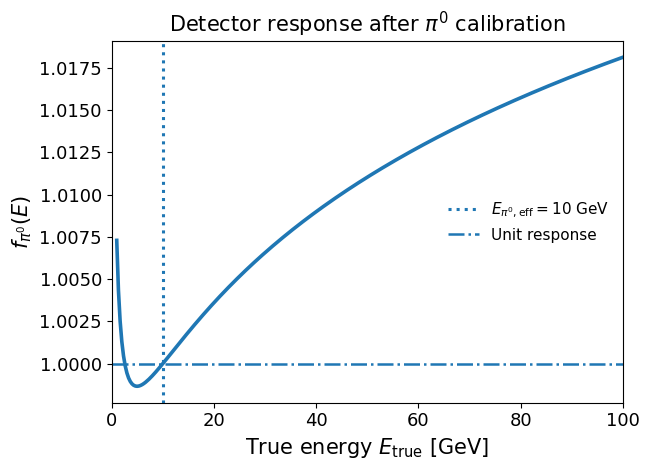

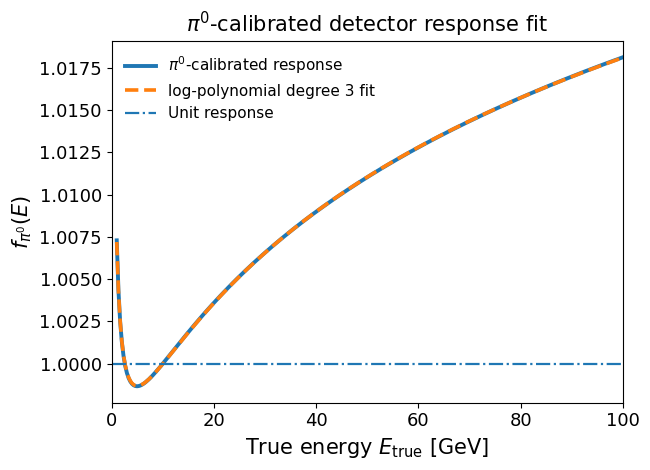

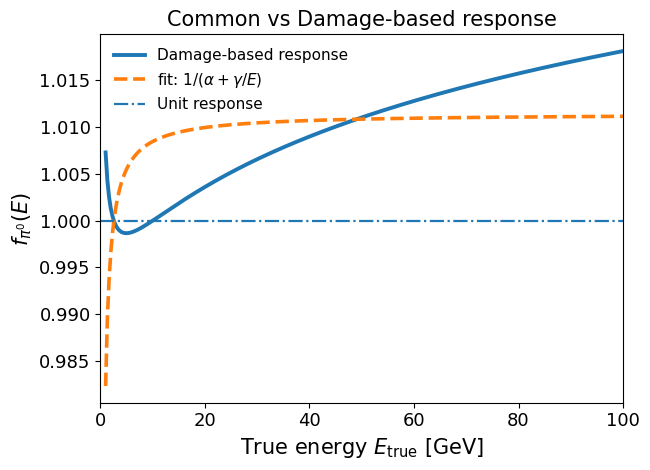

In [9]:

# 24. Fits after pi0 calibration 


from scipy.optimize import curve_fit

# Use pi0-calibrated response as the new fitted response
f_pi0 = f_response_pi0_calibrated



# Log-polynomial degree 3 fit to pi0-calibrated response


def log_poly3(E, a0, a1, a2, a3):
    L = np.log(E)
    return a0 + a1 * L + a2 * L**2 + a3 * L**3


popt_pi0_log, pcov_pi0_log = curve_fit(
    log_poly3,
    E_true_GeV,
    f_pi0,
    p0=[1.0, 0.01, -0.001, 0.0001],
    maxfev=10000
)

perr_pi0_log = np.sqrt(np.diag(pcov_pi0_log))
f_pi0_log_fit = log_poly3(E_true_GeV, *popt_pi0_log)

res_pi0_log = f_pi0 - f_pi0_log_fit
rms_pi0_log = np.sqrt(np.mean(res_pi0_log**2))
chi2_pi0_log = np.sum((res_pi0_log / rms_pi0_log)**2)
dof_pi0_log = len(E_true_GeV) - len(popt_pi0_log)
chi2_dof_pi0_log = chi2_pi0_log / dof_pi0_log

print("\n=== Pi0-calibrated log-polynomial degree 3 fit ===")
print("Fit form:")
print("f_pi0(E) = a0 + a1 log(E) + a2 log(E)^2 + a3 log(E)^3")
print("\nParameters with fit errors:")
print(f"a0 = {popt_pi0_log[0]:.10f} ± {perr_pi0_log[0]:.10f}")
print(f"a1 = {popt_pi0_log[1]:.10f} ± {perr_pi0_log[1]:.10f}")
print(f"a2 = {popt_pi0_log[2]:.10f} ± {perr_pi0_log[2]:.10f}")
print(f"a3 = {popt_pi0_log[3]:.10f} ± {perr_pi0_log[3]:.10f}")
print(f"\nRMS residual = {rms_pi0_log:.6e}")
print(f"chi2/dof = {chi2_pi0_log:.2f}/{dof_pi0_log} = {chi2_dof_pi0_log:.3f}")



# Common parameterization fit to pi0-calibrated response
-

def common_response_model(E, alpha, gamma_param):
    return 1.0 / (alpha + gamma_param / E)


popt_pi0_common, pcov_pi0_common = curve_fit(
    common_response_model,
    E_true_GeV,
    f_pi0,
    p0=[1.0, 0.01],
    maxfev=10000
)

perr_pi0_common = np.sqrt(np.diag(pcov_pi0_common))
f_pi0_common_fit = common_response_model(E_true_GeV, *popt_pi0_common)

res_pi0_common = f_pi0 - f_pi0_common_fit
rms_pi0_common = np.sqrt(np.mean(res_pi0_common**2))
chi2_pi0_common = np.sum((res_pi0_common / rms_pi0_common)**2)
dof_pi0_common = len(E_true_GeV) - len(popt_pi0_common)
chi2_dof_pi0_common = chi2_pi0_common / dof_pi0_common

print("\n=== Pi0-calibrated common response parameterization fit ===")
print("Fit form:")
print("f_pi0(E) = 1 / (alpha + gamma/E)")
print("\nParameters with fit errors:")
print(f"alpha = {popt_pi0_common[0]:.10f} ± {perr_pi0_common[0]:.10f}")
print(f"gamma = {popt_pi0_common[1]:.10f} ± {perr_pi0_common[1]:.10f}")
print(f"\nRMS residual = {rms_pi0_common:.6e}")
print(f"chi2/dof = {chi2_pi0_common:.2f}/{dof_pi0_common} = {chi2_dof_pi0_common:.3f}")



# 25. Plot  of pi0-calibrated response


plt.figure(figsize=(6.6, 4.8))

plt.plot(
    E_true_GeV,
    f_pi0,
    linewidth=2.6
)

plt.axvline(
    E_pi0_eff_GeV,
    linestyle=":",
    linewidth=2.2,
    label=r"$E_{\pi^0,\mathrm{eff}}=10$ GeV"
)

plt.axhline(
    1.0,
    linestyle="-.",
    linewidth=1.8,
    label="Unit response"
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"$f_{\pi^0}(E)$", fontsize=15)
plt.title(r"Detector response after $\pi^0$ calibration", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)
plt.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("pi0_response_curve_clean.png", dpi=300, bbox_inches="tight")
plt.show()



# 26. Plot of pi0-calibrated log-polynomial fit


plt.figure(figsize=(6.6, 4.8))

plt.plot(
    E_true_GeV,
    f_pi0,
    linewidth=2.8,
    label=r"$\pi^0$-calibrated response"
)

plt.plot(
    E_true_GeV,
    f_pi0_log_fit,
    linestyle="--",
    linewidth=2.6,
    label="log-polynomial degree 3 fit"
)

plt.axhline(
    1.0,
    linestyle="-.",
    linewidth=1.6,
    label="Unit response"
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"$f_{\pi^0}(E)$", fontsize=15)
plt.title(r"$\pi^0$-calibrated detector response fit", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)
plt.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("pi0_response_fit_logpoly3_clean.png", dpi=300, bbox_inches="tight")
plt.show()



# 27. Plot of pi0-calibrated common fit


plt.figure(figsize=(6.6, 4.8))

plt.plot(
    E_true_GeV,
    f_pi0,
    linewidth=2.8,
    label=r"Damage-based response"
)

plt.plot(
    E_true_GeV,
    f_pi0_common_fit,
    linestyle="--",
    linewidth=2.6,
    label=r"fit: $1/(\alpha+\gamma/E)$"
)

plt.axhline(
    1.0,
    linestyle="-.",
    linewidth=1.6,
    label="Unit response"
)

plt.xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]", fontsize=15)
plt.ylabel(r"$f_{\pi^0}(E)$", fontsize=15)
plt.title(r"Common vs Damage-based response", fontsize=15)

plt.tick_params(axis="both", labelsize=13)
plt.xlim(0, 100)
plt.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("pi0_response_fit_common_clean.png", dpi=300, bbox_inches="tight")
plt.show()